# FF follow-up — minimal

Only new follow-up material for team discussion.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

MOUSE_ROOT = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new')
FF_DIR = MOUSE_ROOT / 'differential_expression_all20' / 'derived_analysis' / 'ipsi_vs_contra_in_ff'

## Before vs after bend-point — `ipsi_vs_contra_in_ff`

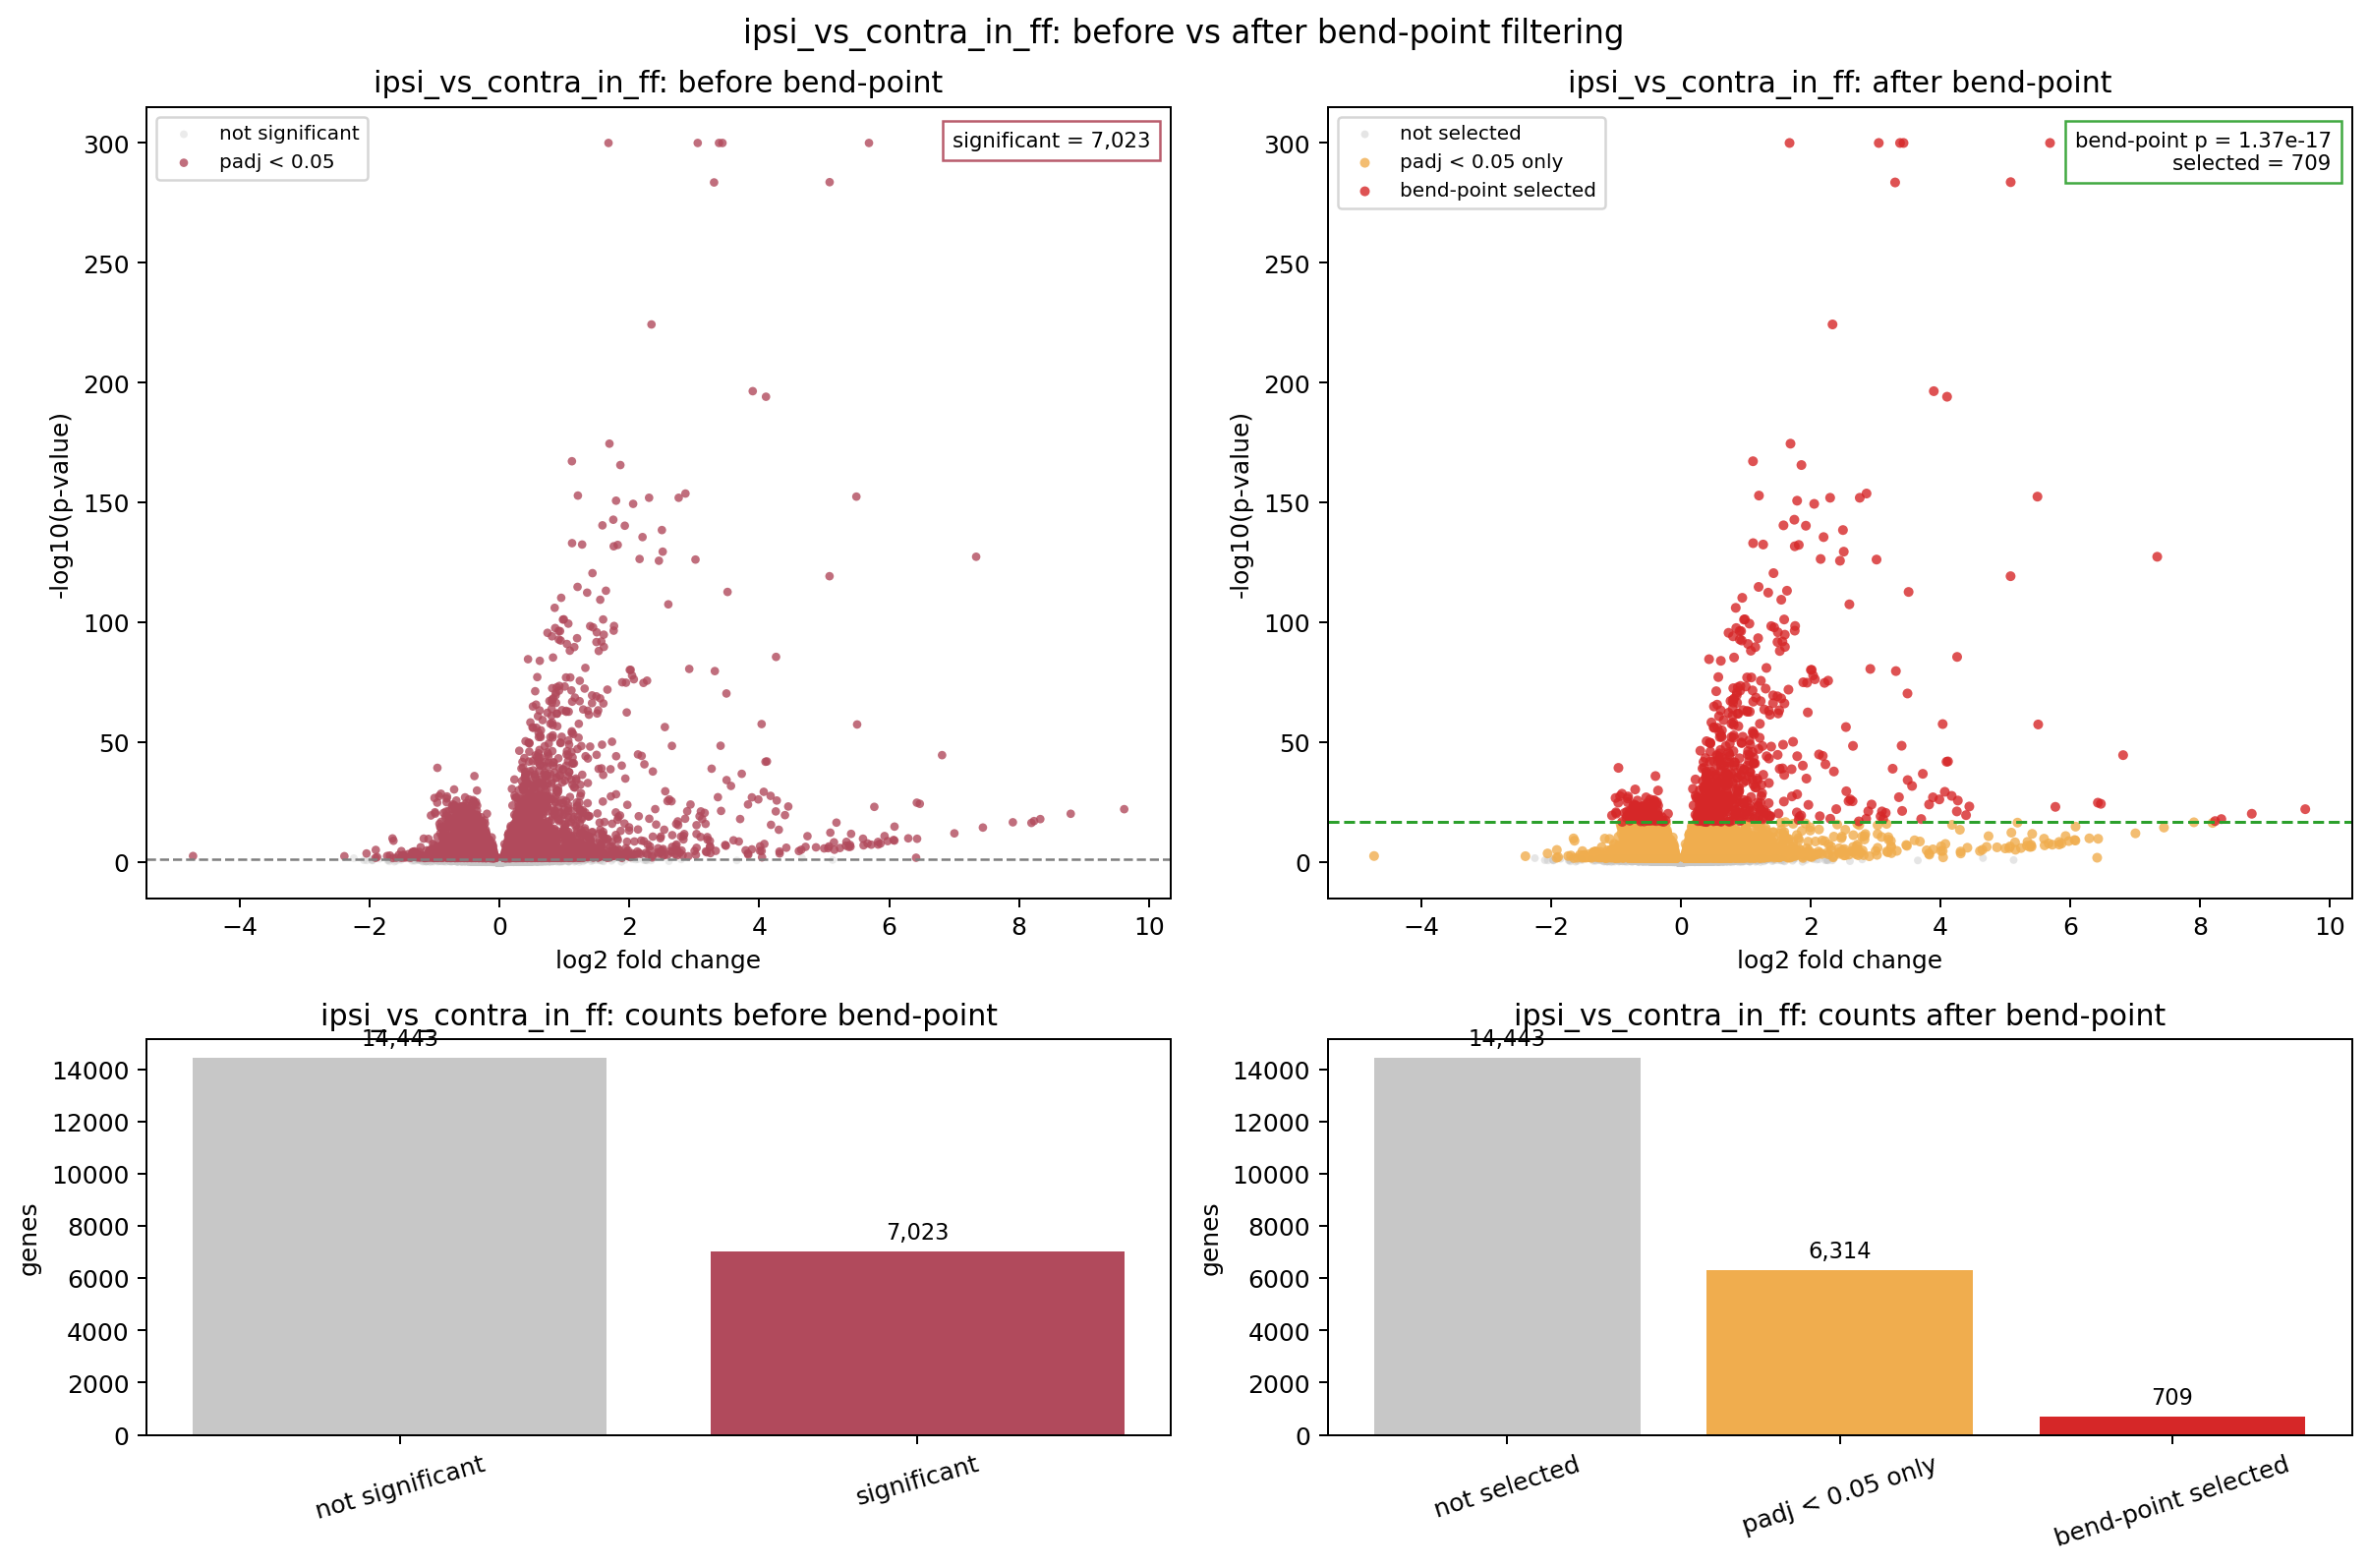

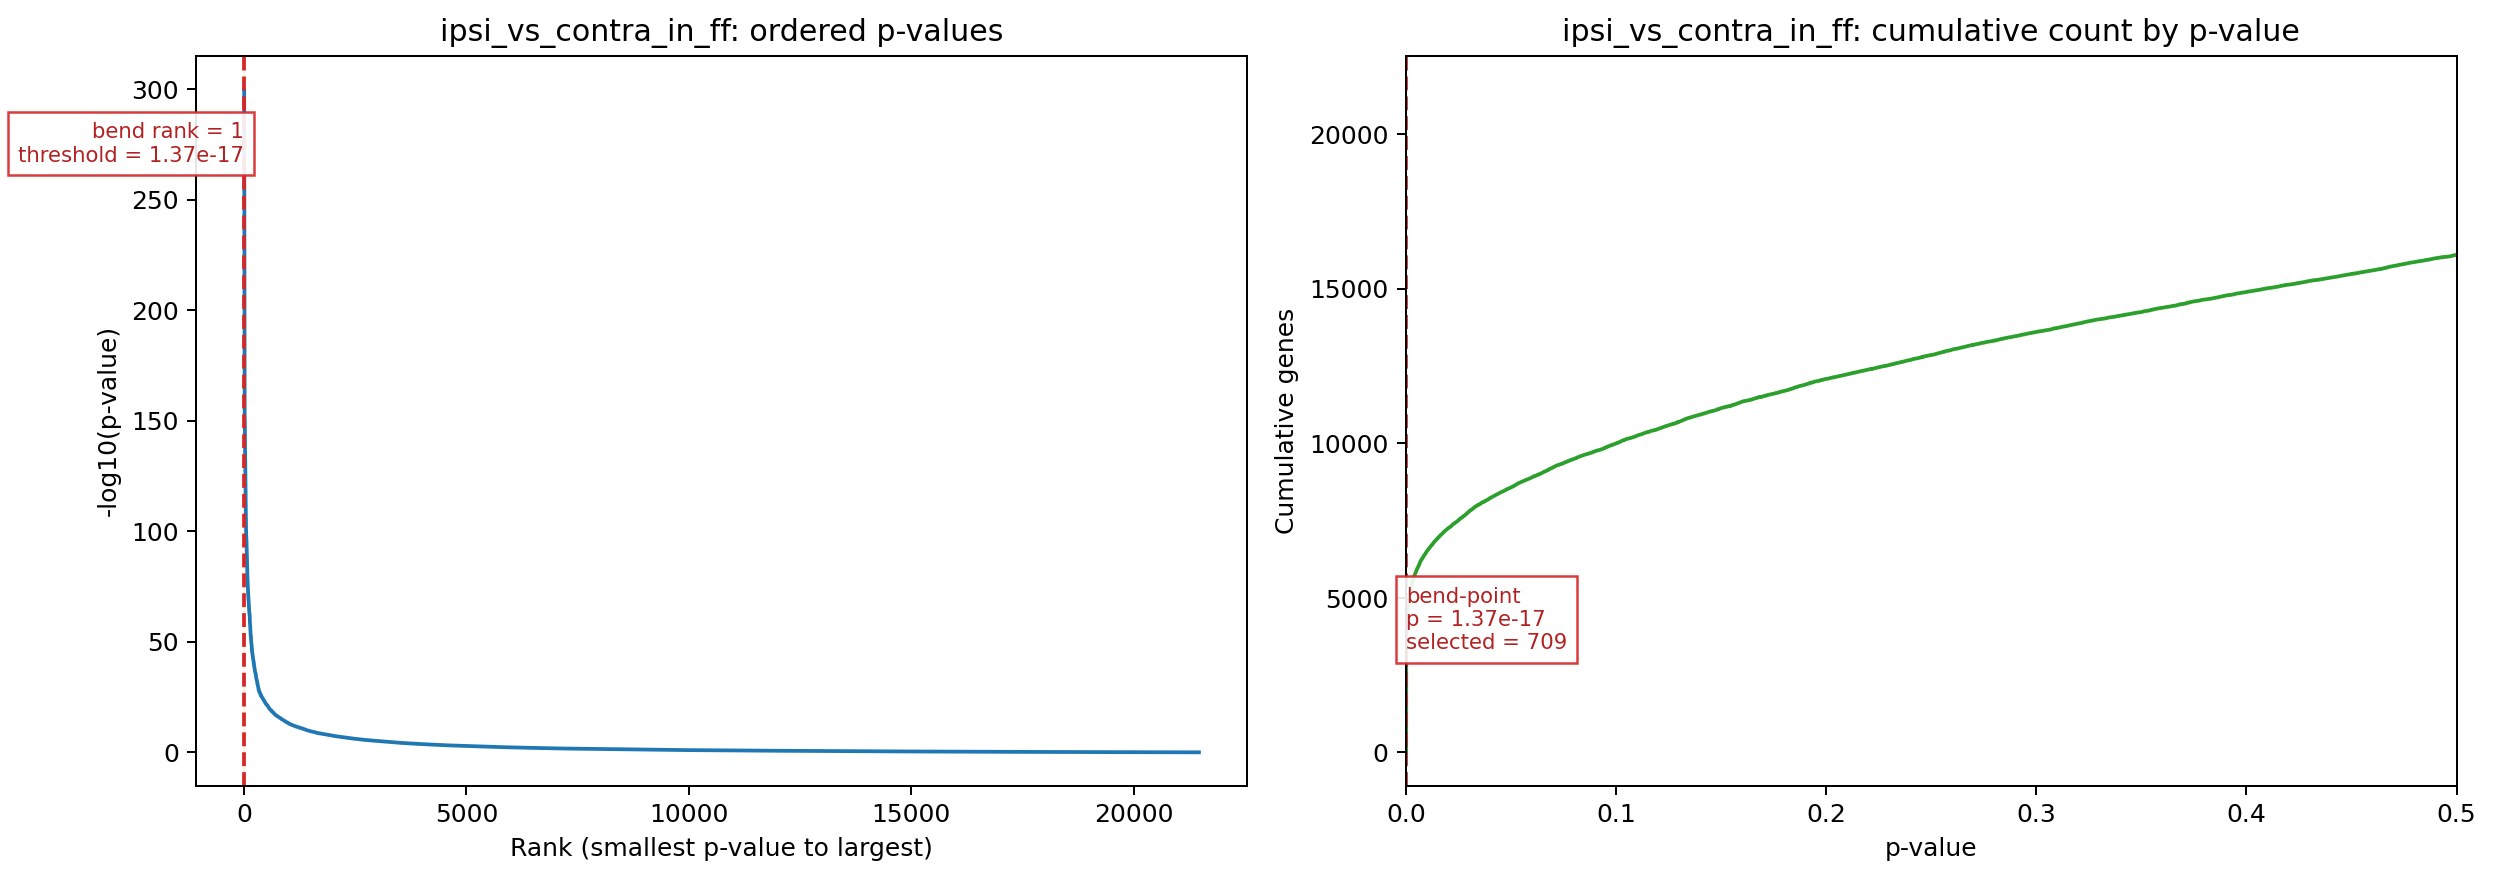

,contrast_id,genes_tested,significant_padj_lt_0_05,bend_pvalue_threshold,genes_below_bendpoint
0,ipsi_vs_contra_in_ff,21466,7023,1.374018e-17,709


In [2]:
display(Image(filename=str(FF_DIR / 'before_after_selection_comparison.png'), width=1050))
display(Image(filename=str(FF_DIR / 'ordered_pvalue_and_cumulative_curve.png'), width=1050))
display(pd.read_csv(FF_DIR / 'bendpoint_summary.tsv', sep='	'))

## Anchor-gene companion table — `ipsi_vs_contra_in_ff`

In [3]:
anchor_df = pd.read_csv(FF_DIR / 'selected_genes_bendpoint.tsv', sep='	')
symbol_path = FF_DIR / 'selected_genes_bendpoint_gene_symbols.tsv'
if symbol_path.exists():
    symbol_df = pd.read_csv(symbol_path, sep='	').drop_duplicates('gene_id')
    anchor_df = anchor_df.merge(symbol_df, on='gene_id', how='left')
else:
    anchor_df['symbol'] = anchor_df['gene_id']
anchor_df['symbol'] = anchor_df['symbol'].fillna(anchor_df['gene_id'])
anchor_df['Direction'] = anchor_df['log2FoldChange'].gt(0).map({True: 'Upregulated', False: 'Downregulated'})
anchor_df['abs_log2FoldChange'] = anchor_df['log2FoldChange'].abs()
anchor_table = pd.concat([
    anchor_df[anchor_df['log2FoldChange'] > 0].sort_values(['padj', 'abs_log2FoldChange'], ascending=[True, False]).head(5),
    anchor_df[anchor_df['log2FoldChange'] < 0].sort_values(['padj', 'abs_log2FoldChange'], ascending=[True, False]).head(5),
], ignore_index=True).copy()
anchor_table['Gene symbol'] = anchor_table['symbol']
anchor_table['Gene ID'] = anchor_table['gene_id']
anchor_table['Selection note'] = 'top within bend-point core by padj'
anchor_table = anchor_table[['Direction', 'Gene symbol', 'Gene ID', 'log2FoldChange', 'padj', 'Selection note']]
anchor_table.to_csv(FF_DIR / 'anchor_genes_up_down.tsv', sep='	', index=False)
display(anchor_table)

,Direction,Gene symbol,Gene ID,log2FoldChange,padj,Selection note
0,Upregulated,Atf3,ENSMUSG00000026628,5.689282,0.000000e+00,top within bend-point core by padj
1,Upregulated,Flrt3,ENSMUSG00000051379,3.432440,0.000000e+00,top within bend-point core by padj
2,Upregulated,Gadd45a,ENSMUSG00000036390,3.378730,0.000000e+00,top within bend-point core by padj
3,Upregulated,Sox11,ENSMUSG00000063632,3.051050,2.239759e-311,top within bend-point core by padj
4,Upregulated,Jun,ENSMUSG00000052684,1.676557,2.543762e-306,top within bend-point core by padj
5,Downregulated,Vwc2l,ENSMUSG00000045648,-0.959394,3.704359e-38,top within bend-point core by padj
6,Downregulated,Hdac11,ENSMUSG00000034245,-0.389180,8.581183e-35,top within bend-point core by padj
7,Downregulated,B3gnt8,ENSMUSG00000059479,-0.701388,2.773910e-29,top within bend-point core by padj
8,Downregulated,Pik3r2,ENSMUSG00000031834,-0.349357,7.563062e-29,top within bend-point core by padj
9,Downregulated,Oprl1,ENSMUSG00000027584,-0.904441,1.584197e-27,top within bend-point core by padj


## Direction-split GO follow-up — `ipsi_vs_contra_in_ff`

,set,n_genes
0,selected,709
1,up (log2FC > 0),607
2,down (log2FC < 0),102
3,zero,0


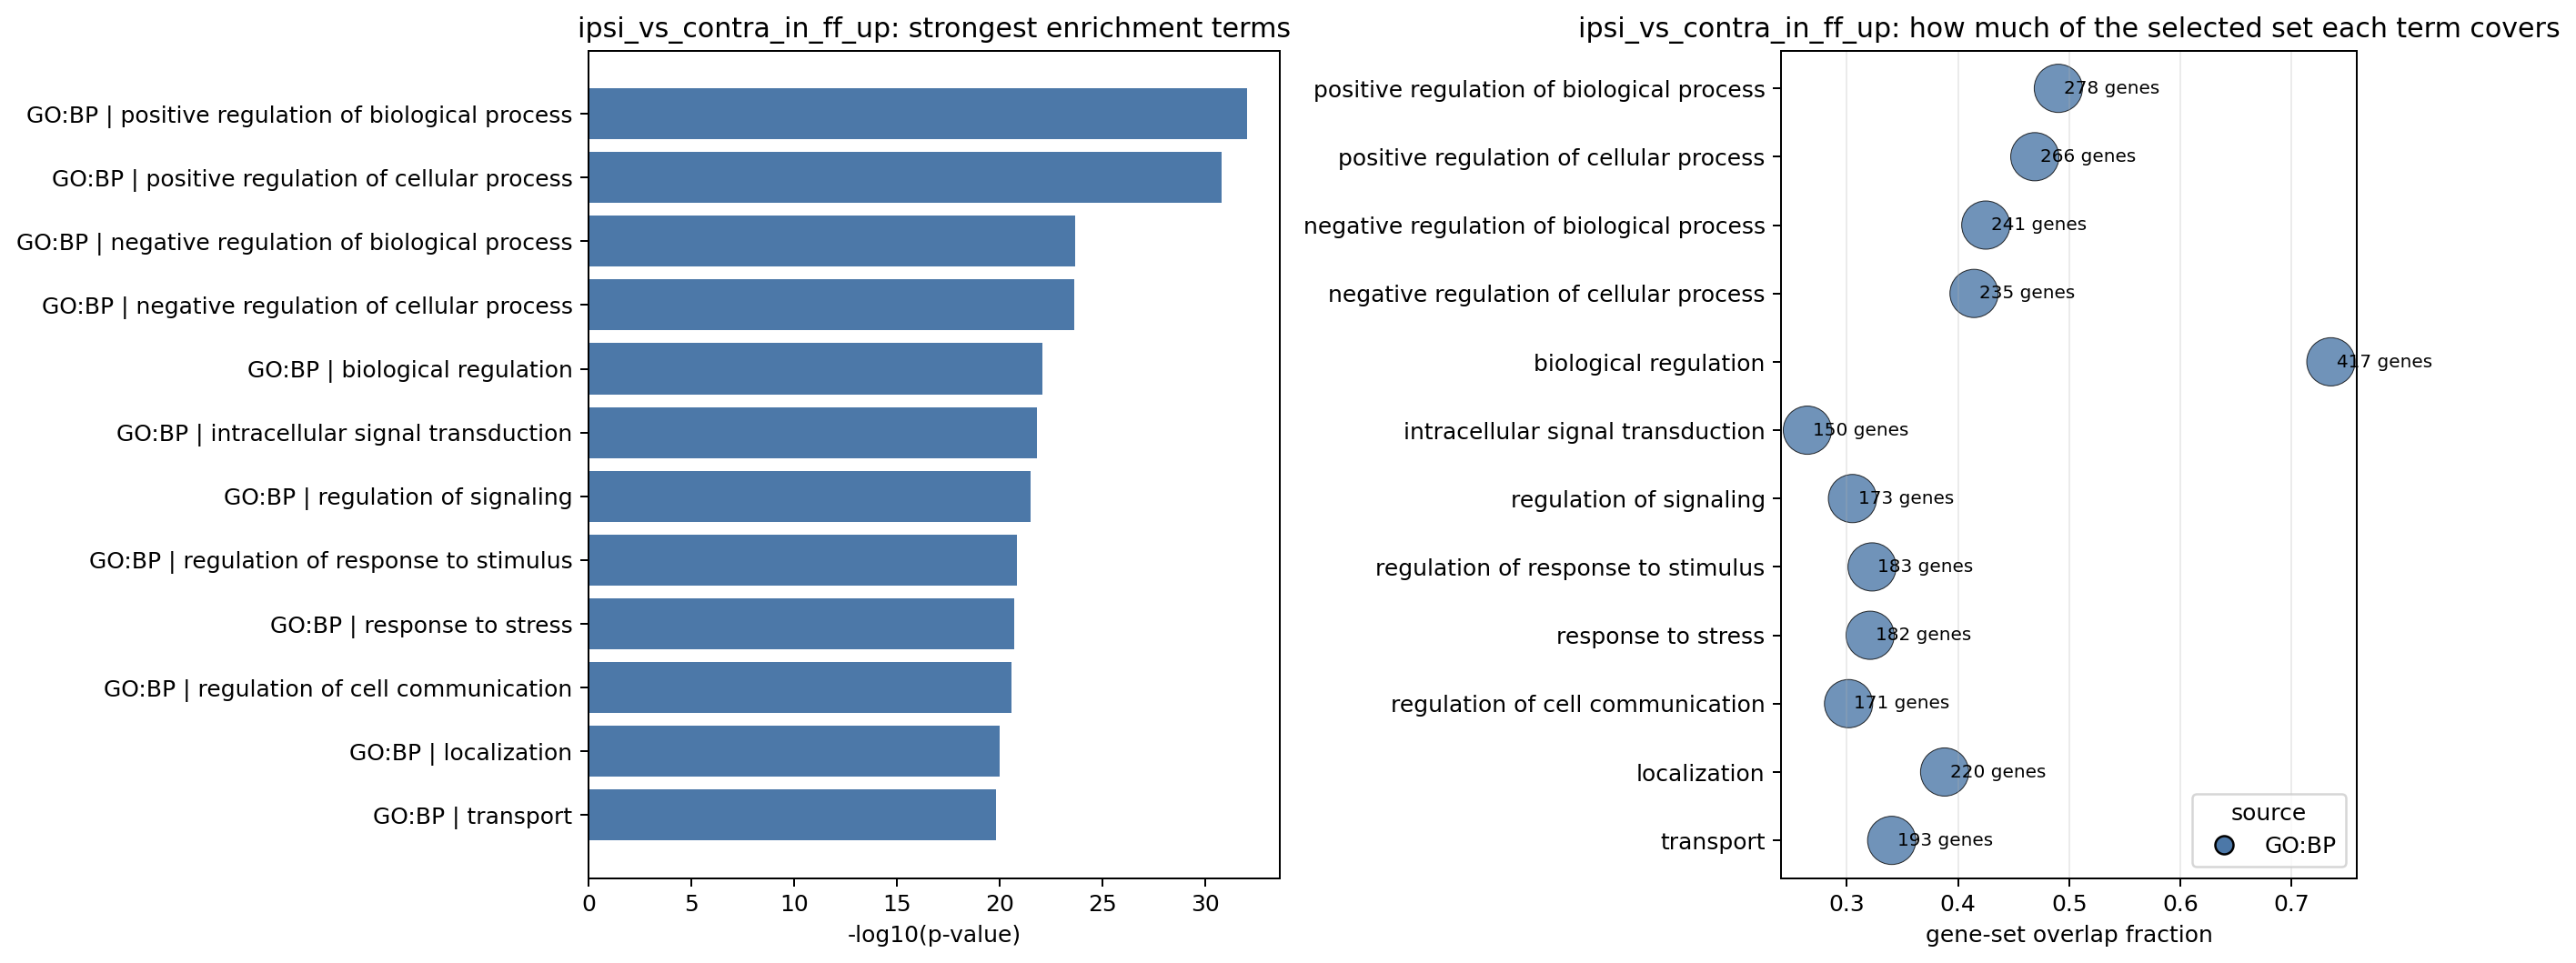

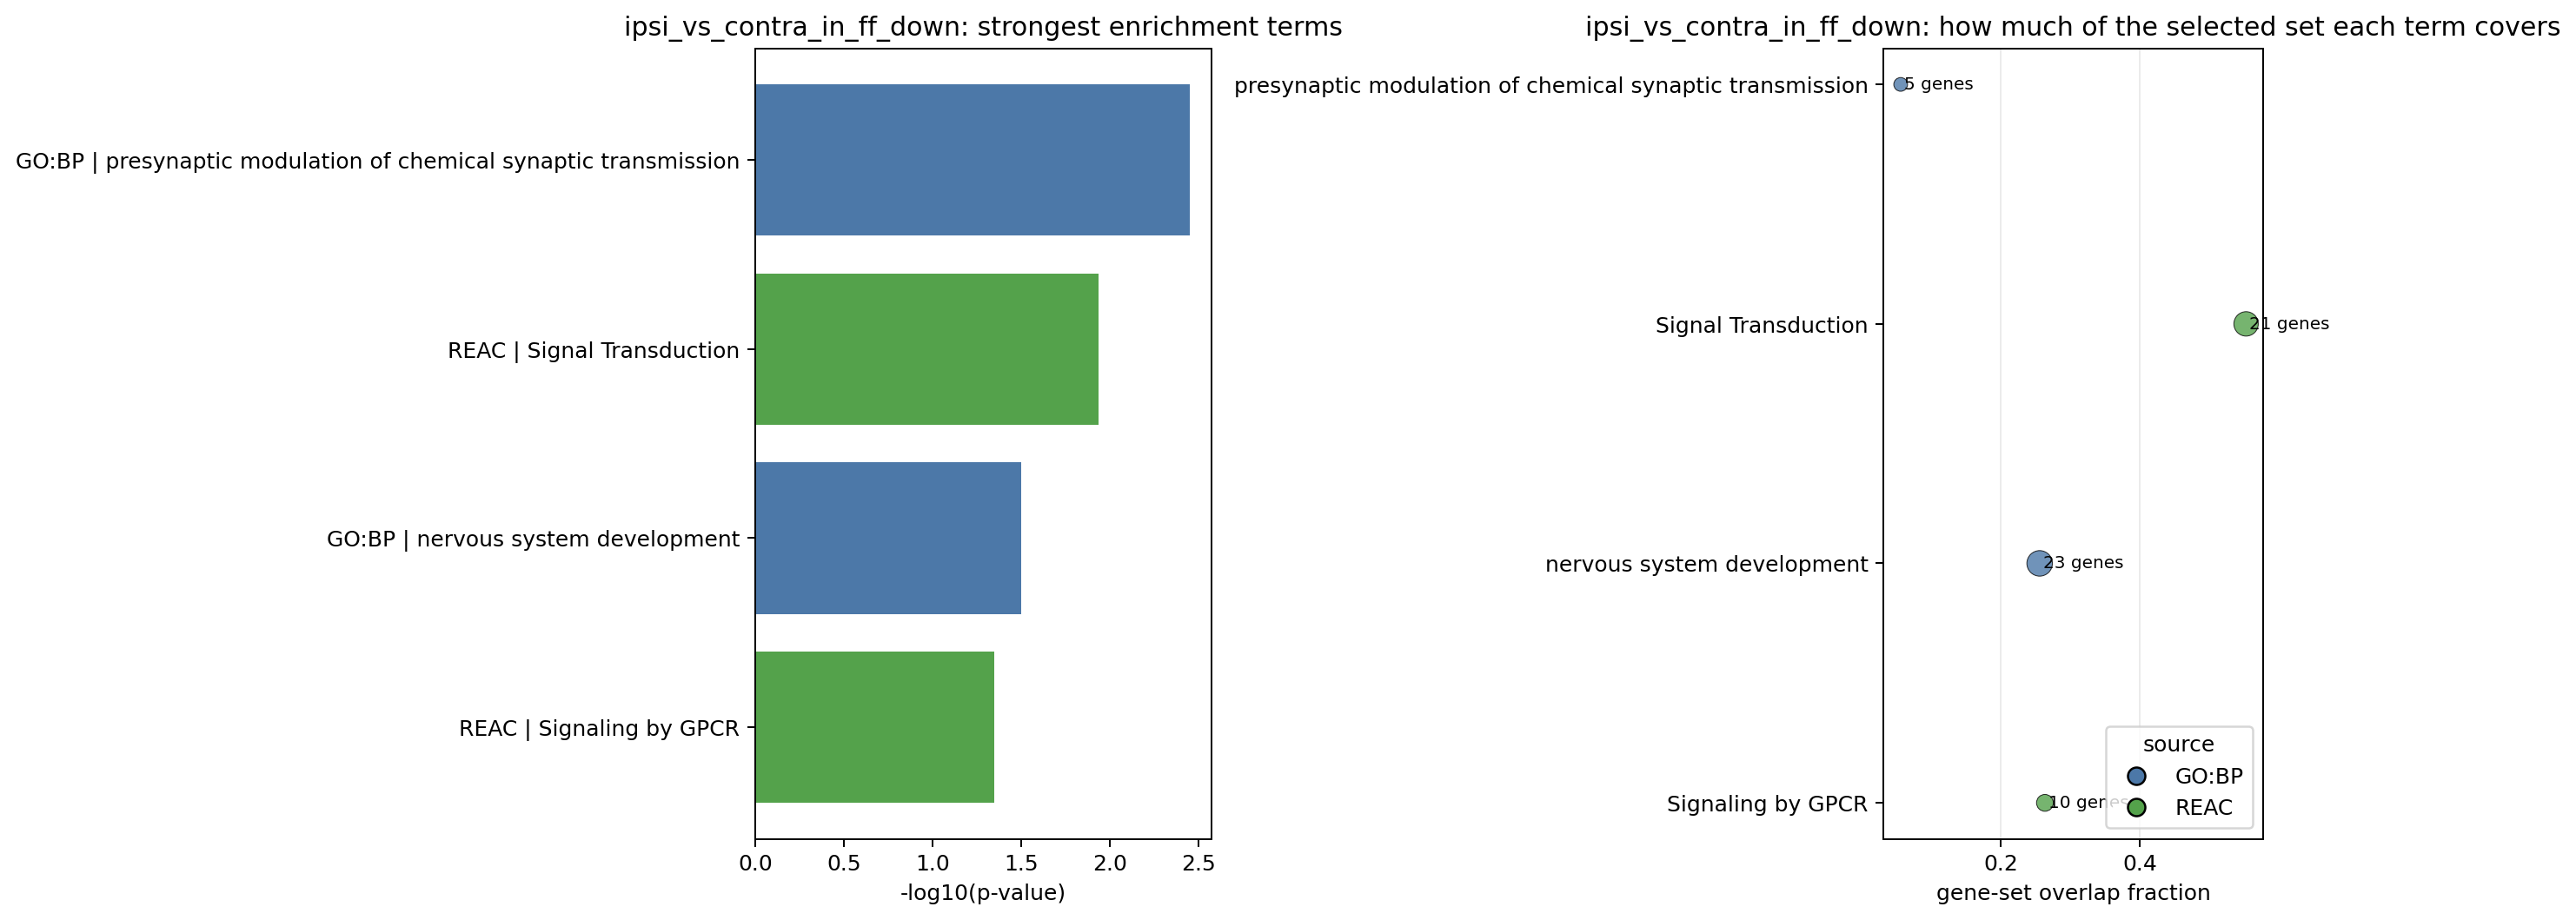

,contrast_id,gene_set_used,source,native,name,p_value,term_size,query_size,intersection_size,effective_domain_size,parents
0,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0048518,positive regulation of biological process,9.893579e-33,6447,567,278,25907,"['GO:0008150', 'GO:0050789']"
1,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0048522,positive regulation of cellular process,1.628116e-31,6095,567,266,25907,"['GO:0009987', 'GO:0048518', 'GO:0050794']"
2,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0048519,negative regulation of biological process,2.298483e-24,5759,567,241,25907,"['GO:0008150', 'GO:0050789']"
3,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0048523,negative regulation of cellular process,2.389344e-24,5540,567,235,25907,"['GO:0009987', 'GO:0048519', 'GO:0050794']"
4,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0065007,biological regulation,8.504132e-23,13503,567,417,25907,['GO:0008150']
5,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0035556,intracellular signal transduction,1.540069e-22,2810,567,150,25907,['GO:0007165']
6,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0023051,regulation of signaling,3.060739e-22,3558,567,173,25907,"['GO:0023052', 'GO:0050789']"
7,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0048583,regulation of response to stimulus,1.423328e-21,3939,567,183,25907,"['GO:0050789', 'GO:0050896']"
8,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0006950,response to stress,2.020976e-21,3917,567,182,25907,['GO:0050896']
9,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC > 0),GO:BP,GO:0010646,regulation of cell communication,2.630694e-21,3560,567,171,25907,"['GO:0007154', 'GO:0050794']"


,contrast_id,gene_set_used,source,native,name,p_value,term_size,query_size,intersection_size,effective_domain_size,parents
0,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC < 0),GO:BP,GO:0099171,presynaptic modulation of chemical synaptic tr...,0.003540,60,90,5,25907,['GO:0050804']
1,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC < 0),REAC,REAC:R-MMU-162582,Signal Transduction,0.011534,2073,38,21,8469,['REAC:0000000']
2,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC < 0),GO:BP,GO:0007399,nervous system development,0.031554,2593,90,23,25907,['GO:0048731']
3,ipsi_vs_contra_in_ff,bend-point selected genes (log2FC < 0),REAC,REAC:R-MMU-372790,Signaling by GPCR,0.044729,581,38,10,8469,['REAC:R-MMU-162582']


In [4]:
ff = pd.read_csv(FF_DIR / 'selected_genes_bendpoint.tsv', sep='	')
summary = pd.DataFrame({
    'set': ['selected', 'up (log2FC > 0)', 'down (log2FC < 0)', 'zero'],
    'n_genes': [
        int(len(ff)),
        int((ff['log2FoldChange'] > 0).sum()),
        int((ff['log2FoldChange'] < 0).sum()),
        int((ff['log2FoldChange'] == 0).sum()),
    ]
})
display(summary)
display(Image(filename=str(FF_DIR / 'gprofiler_terms_and_overlap_up.png'), width=1150))
display(Image(filename=str(FF_DIR / 'gprofiler_terms_and_overlap_down.png'), width=1150))
display(pd.read_csv(FF_DIR / 'gprofiler_enrichment_up.tsv', sep='	').head(10))
display(pd.read_csv(FF_DIR / 'gprofiler_enrichment_down.tsv', sep='	').head(10))

**Team note:** Keep the GO split by direction. The upregulated side carries most of the interpretable signal; the downregulated side is weaker and should be treated more cautiously.

## Pathway themes to investigate

In [5]:
ff_theme_table = (
    pd.read_csv(FF_DIR / 'gprofiler_enrichment.tsv', sep='	')
    .loc[:, ['source', 'name', 'p_value', 'intersection_size']]
    .query("source in ['GO:BP', 'KEGG', 'REAC']")
    .head(12)
    .copy()
)
display(ff_theme_table)

,source,name,p_value,intersection_size
0,GO:BP,positive regulation of biological process,9.427224e-32,308
1,GO:BP,positive regulation of cellular process,8.454629e-31,295
2,GO:BP,negative regulation of biological process,1.114633e-24,270
3,GO:BP,regulation of signaling,1.717882e-24,197
4,GO:BP,negative regulation of cellular process,3.268086e-24,262
5,GO:BP,intracellular signal transduction,4.320748e-24,169
6,GO:BP,regulation of cell communication,1.429176e-23,195
7,GO:BP,biological regulation,5.557276e-23,474
8,GO:BP,system development,3.999491e-22,212
9,GO:BP,localization,6.068204e-22,249


- injury response
- regeneration response
- stress / inflammation